In [2]:
# ============================================================
# CELL 1: Imports + Data Loading
# ============================================================
# Analysis notebook for comparing AI agent vs Human taught
# evaluation metrics (checkpoints + stagnation)
#
# Expected directory structure:
#   cogai/jsons/ai_logs/checkpoint_metrics.json
#   cogai/jsons/ai_logs/stagnation_metrics.json
#   cogai/jsons/taught_logs/aggregated_checkpoint_eval.json
#   cogai/jsons/taught_logs/aggregated_stagnation_eval.json
#   cogai/jsons/log_analysis/   ← output plots go here
# ============================================================

import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from collections import defaultdict

# ── Paths ──────────────────────────────────────────────────
BASE = r"C:\Users\HP\Documents\cogai\jsons"

AI_CHECKPOINT_PATH = os.path.join(BASE, "logs", "ai_logs", "checkpoint_metrics.json")
AI_STAGNATION_PATH = os.path.join(BASE, "logs", "ai_logs", "stagnation_metrics.json")
HUMAN_CHECKPOINT_PATH = os.path.join(BASE, "logs", "taught_logs", "aggregated_checkpoint_metrics.json")
HUMAN_STAGNATION_PATH = os.path.join(BASE, "logs", "taught_logs", "aggregated_stagnation_metrics.json")

OUTPUT_DIR = os.path.join(BASE, "log_analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load JSON files ────────────────────────────────────────
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

ai_cp = load_json(AI_CHECKPOINT_PATH)
ai_stag = load_json(AI_STAGNATION_PATH)
human_cp = load_json(HUMAN_CHECKPOINT_PATH)
human_stag = load_json(HUMAN_STAGNATION_PATH)

# ── Map name lookup ────────────────────────────────────────
MAP_NAMES = {
    11: "Player House 2F",
    13: "Pallet Town",
    14: "Viridian PC",
    15: "Oak's Lab",
    17: "Player House 1F",
    21: "Rival House",
    22: "Route 22",
    23: "Route 1",
    24: "Pewter Gym",
    25: "Viridian City",
    31: "Route 2",
    33: "Viridian Mart",
    34: "Pewter City",
    35: "Route 22 Gate",
    36: "Pewter Museum",
    43: "Route 2 Gate",
    81: "Viridian Forest",
    91: "Diglett Cave",
    172: "Mt Moon",
    232: "Cerulean City",
}

def map_name(map_id):
    return MAP_NAMES.get(map_id, f"Map {map_id}")

# ── Plot styling ───────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#0f1117',
    'axes.edgecolor': '#2a2e3a',
    'axes.labelcolor': '#c8cdd5',
    'text.color': '#c8cdd5',
    'xtick.color': '#8890a0',
    'ytick.color': '#8890a0',
    'grid.color': '#1e2230',
    'grid.alpha': 0.6,
    'legend.facecolor': '#181c25',
    'legend.edgecolor': '#2a2e3a',
    'legend.labelcolor': '#c8cdd5',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': '#0f1117',
    'savefig.pad_inches': 0.3,
})

COLOR_AI = '#f97316'       # orange
COLOR_HUMAN = '#3b82f6'    # blue
COLOR_ACCENT = '#10b981'   # green
COLOR_WARN = '#f43f5e'     # red
COLOR_GRID = '#1e2230'

# ── Quick validation ───────────────────────────────────────
print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"\nAI Checkpoints:  {ai_cp['metadata']['total_checkpoints']} events, {ai_cp['metadata']['total_timesteps']} steps")
print(f"  Maps visited:  {[map_name(m) for m in ai_cp['metadata']['maps_visited']]}")
print(f"  Source:        {ai_cp['metadata']['source']}")

print(f"\nAI Stagnation:   {ai_stag['metadata']['total_snapshots']} snapshots")
print(f"  Raw ratio:     {ai_stag['metadata']['stagnation_ratio']:.3f}")
print(f"  Types:         {ai_stag['metadata']['stagnation_types']}")

print(f"\nHuman Checkpoints: {len(human_cp['aggregated_checkpoints'])} matched checkpoints across {human_cp['metadata']['runs_analyzed']} runs")
print(f"  Threshold:     {human_cp['metadata']['match_threshold']}")

print(f"\nHuman Stagnation:  {human_stag['aggregated_overall']['runs_analyzed']} runs analyzed")
print(f"  Avg dedup ratio: {human_stag['aggregated_overall']['avg_deduplicated_stagnation_ratio']:.3f}")
print(f"  Types observed:  {human_stag['metadata']['stagnation_types_observed']}")

# Count matched maps
ai_maps = set(ai_cp['metadata']['maps_visited'])
human_maps = set()
for cp in human_cp['aggregated_checkpoints']:
    if cp['event_type'] == 'new_map':
        human_maps.add(cp['event_detail']['new_map_id'])

shared_maps = ai_maps & human_maps
print(f"\nShared maps:     {len(shared_maps)} — {[map_name(m) for m in sorted(shared_maps)]}")
print(f"AI only:         {len(ai_maps - human_maps)} — {[map_name(m) for m in sorted(ai_maps - human_maps)]}")
print(f"Human only:      {len(human_maps - ai_maps)} — {[map_name(m) for m in sorted(human_maps - ai_maps)]}")

print(f"\nOutput dir:      {OUTPUT_DIR}")
print("=" * 60)

DATA LOADED

AI Checkpoints:  11 events, 8255 steps
  Maps visited:  ['Player House 2F', 'Viridian PC', "Oak's Lab", 'Player House 1F', 'Route 1', 'Viridian City', 'Route 2', 'Viridian Mart', 'Route 22 Gate', 'Route 2 Gate', 'Viridian Forest']
  Source:        ai_agent_live

AI Stagnation:   119 snapshots
  Raw ratio:     1.291
  Types:         {'action_pattern': 39, 'position_stuck': 27, 'backtracking': 41, 'area_grinding': 11, 'action_repeat': 1}

Human Checkpoints: 16 matched checkpoints across 3 runs
  Threshold:     0.75

Human Stagnation:  3 runs analyzed
  Avg dedup ratio: 0.787
  Types observed:  ['action_pattern', 'action_repeat', 'area_grinding', 'no_map_progress']

Shared maps:     8 — ['Player House 2F', 'Viridian PC', 'Route 1', 'Route 2', 'Viridian Mart', 'Route 22 Gate', 'Route 2 Gate', 'Viridian Forest']
AI only:         3 — ["Oak's Lab", 'Player House 1F', 'Viridian City']
Human only:      7 — ['Map 12', 'Rival House', 'Route 22', 'Pewter Gym', 'Pewter Museum', 'Mt Moo

In [3]:
# ============================================================
# CELL 2: AI Stagnation Deduplication
# ============================================================
# The AI's raw stagnation_ratio (1.291) counts overlapping
# concurrent stagnation events multiple times. For example,
# if position_stuck and backtracking overlap for 50 frames,
# both contribute 50 frames to the raw total = 100 counted.
#
# The human aggregate uses deduplicated intervals (merging
# overlaps), giving a true wall-clock stagnation percentage.
# We apply the same methodology here for apples-to-apples.
# ============================================================

# ── Extract all stagnation intervals ───────────────────────
ai_intervals = []
for snap in ai_stag['snapshots']:
    ai_intervals.append((snap['timestep_start'], snap['timestep_end']))

print(f"Raw intervals: {len(ai_intervals)}")
print(f"Raw total frames: {ai_stag['metadata']['total_stagnation_frames']}")
print(f"Raw ratio: {ai_stag['metadata']['stagnation_ratio']:.3f}")

# ── Merge overlapping intervals ────────────────────────────
def merge_intervals(intervals):
    """Merge overlapping/adjacent intervals into non-overlapping set."""
    if not intervals:
        return []
    
    # Sort by start time
    sorted_intervals = sorted(intervals, key=lambda x: x[0])
    merged = [sorted_intervals[0]]
    
    for start, end in sorted_intervals[1:]:
        prev_start, prev_end = merged[-1]
        if start <= prev_end:
            # Overlapping or adjacent — extend
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            # Gap — new interval
            merged.append((start, end))
    
    return merged

merged = merge_intervals(ai_intervals)
dedup_frames = sum(end - start for start, end in merged)
total_steps = ai_stag['metadata']['total_timesteps']
dedup_ratio = dedup_frames / total_steps if total_steps > 0 else 0

# ── Store for later cells ─────────────────────────────────
ai_dedup = {
    'raw_intervals': len(ai_intervals),
    'merged_intervals': len(merged),
    'raw_frames': ai_stag['metadata']['total_stagnation_frames'],
    'dedup_frames': dedup_frames,
    'total_steps': total_steps,
    'raw_ratio': ai_stag['metadata']['stagnation_ratio'],
    'dedup_ratio': dedup_ratio,
    'merged': merged,
}

# ── Per-type breakdown ─────────────────────────────────────
ai_type_stats = {}
type_intervals = defaultdict(list)
for snap in ai_stag['snapshots']:
    stype = snap['stagnation_type']
    type_intervals[stype].append((snap['timestep_start'], snap['timestep_end']))

for stype, intervals in type_intervals.items():
    raw_frames = sum(e - s for s, e in intervals)
    merged_type = merge_intervals(intervals)
    dedup_type_frames = sum(e - s for s, e in merged_type)
    ai_type_stats[stype] = {
        'count': len(intervals),
        'raw_frames': raw_frames,
        'dedup_frames': dedup_type_frames,
        'mean_duration': raw_frames / len(intervals) if intervals else 0,
    }

# ── Print results ──────────────────────────────────────────
print(f"\n{'=' * 60}")
print("AI STAGNATION DEDUPLICATION")
print(f"{'=' * 60}")
print(f"\n{'Metric':<30} {'Raw':>12} {'Deduplicated':>14}")
print(f"{'-' * 56}")
print(f"{'Intervals':<30} {len(ai_intervals):>12} {len(merged):>14}")
print(f"{'Stagnation frames':<30} {ai_stag['metadata']['total_stagnation_frames']:>12} {dedup_frames:>14}")
print(f"{'Stagnation ratio':<30} {ai_stag['metadata']['stagnation_ratio']:>12.3f} {dedup_ratio:>14.3f}")
print(f"{'Total timesteps':<30} {total_steps:>12}")

print(f"\n{'Type':<20} {'Count':>6} {'Raw Frames':>12} {'Dedup Frames':>13} {'Avg Duration':>13}")
print(f"{'-' * 64}")
for stype in sorted(ai_type_stats.keys(), key=lambda t: ai_type_stats[t]['count'], reverse=True):
    s = ai_type_stats[stype]
    print(f"{stype:<20} {s['count']:>6} {s['raw_frames']:>12} {s['dedup_frames']:>13} {s['mean_duration']:>13.1f}")

# ── Compare with human ─────────────────────────────────────
human_dedup_ratio = human_stag['aggregated_overall']['avg_deduplicated_stagnation_ratio']
print(f"\n{'=' * 60}")
print("COMPARISON: Deduplicated Stagnation Ratio")
print(f"{'=' * 60}")
print(f"  AI agent:     {dedup_ratio:.3f} ({dedup_ratio*100:.1f}% of session in stagnation)")
print(f"  Human avg:    {human_dedup_ratio:.3f} ({human_dedup_ratio*100:.1f}% of session in stagnation)")
diff = dedup_ratio - human_dedup_ratio
if diff > 0:
    print(f"  Difference:   AI is {diff:.3f} higher ({diff/human_dedup_ratio*100:.1f}% worse)")
else:
    print(f"  Difference:   AI is {abs(diff):.3f} lower ({abs(diff)/human_dedup_ratio*100:.1f}% better)")
print(f"{'=' * 60}")

Raw intervals: 119
Raw total frames: 10657
Raw ratio: 1.291

AI STAGNATION DEDUPLICATION

Metric                                  Raw   Deduplicated
--------------------------------------------------------
Intervals                               119             44
Stagnation frames                     10657           5897
Stagnation ratio                      1.291          0.714
Total timesteps                        8255

Type                  Count   Raw Frames  Dedup Frames  Avg Duration
----------------------------------------------------------------
backtracking             41         3986          3986          97.2
action_pattern           39         1340          1340          34.4
position_stuck           27         1927          1927          71.4
area_grinding            11         3365          3365         305.9
action_repeat             1           39            39          39.0

COMPARISON: Deduplicated Stagnation Ratio
  AI agent:     0.714 (71.4% of session in stagnat

In [4]:
# ============================================================
# CELL 3: Data Alignment
# ============================================================
# Match AI and human checkpoints on shared maps, build
# comparison structures for all downstream plots.
# Only includes maps up to the AI's furthest checkpoint.
# ============================================================

# ── Determine AI's furthest map ───────────────────────────
ai_checkpoints = ai_cp['checkpoints']
ai_final_ts = ai_checkpoints[-1]['timestep']
ai_final_map = ai_checkpoints[-1]['map_id']
ai_visited_maps = [cp['map_id'] for cp in ai_checkpoints]

print(f"AI furthest checkpoint: Map {ai_final_map} ({map_name(ai_final_map)}) at timestep {ai_final_ts}")
print(f"AI visit order: {[map_name(m) for m in ai_visited_maps]}")

# ── Build AI checkpoint lookup (by map_id) ─────────────────
# Use first visit to each map (some maps may be revisited)
ai_by_map = {}
for cp in ai_checkpoints:
    mid = cp['map_id']
    if mid not in ai_by_map:
        ai_by_map[mid] = {
            'map_id': mid,
            'timestep': cp['timestep'],
            'frames_from_previous': cp['frames_from_previous'],
            'level': cp['team_avg_level'],
            'hp': cp['avg_party_hp_ratio'],
            'checkpoint_id': cp['checkpoint_id'],
        }

# ── Build human checkpoint lookup (by map_id) ─────────────
human_by_map = {}
for cp in human_cp['aggregated_checkpoints']:
    if cp['event_type'] == 'new_map':
        mid = cp['event_detail']['new_map_id']
        human_by_map[mid] = {
            'map_id': mid,
            'avg_timestep': cp['avg_timestep'],
            'avg_frames': cp['avg_frames_from_previous'],
            'std_frames': cp['std_frames_from_previous'],
            'avg_level': cp['avg_team_avg_level'],
            'std_level': cp['std_team_avg_level'],
            'avg_hp': cp['avg_party_hp_ratio'],
            'std_hp': cp['std_party_hp_ratio'],
            'runs_matched': cp['runs_matched'],
        }

# ── Find shared maps (capped at AI's furthest) ────────────
shared_map_ids = sorted(set(ai_by_map.keys()) & set(human_by_map.keys()))
print(f"\nAll shared maps: {[map_name(m) for m in shared_map_ids]}")

# ── Build comparison list in AI visit order ────────────────
# Preserve the order the AI actually visited maps
comparison = []
seen = set()
for mid in ai_visited_maps:
    if mid in human_by_map and mid not in seen:
        seen.add(mid)
        a = ai_by_map[mid]
        h = human_by_map[mid]
        comparison.append({
            'map_id': mid,
            'name': map_name(mid),
            # Frames
            'ai_frames': a['frames_from_previous'],
            'human_frames': h['avg_frames'],
            'human_frames_std': h['std_frames'],
            'efficiency_ratio': a['frames_from_previous'] / h['avg_frames'] if h['avg_frames'] > 0 else float('inf'),
            # Timestep (cumulative)
            'ai_timestep': a['timestep'],
            'human_timestep': h['avg_timestep'],
            # Level
            'ai_level': a['level'],
            'human_level': h['avg_level'],
            'human_level_std': h['std_level'],
            # HP
            'ai_hp': a['hp'],
            'human_hp': h['avg_hp'],
            'human_hp_std': h['std_hp'],
        })

print(f"Matched maps (AI order): {[c['name'] for c in comparison]}")
print(f"Total matched: {len(comparison)}")

# ── AI-only maps (visited by AI but not in human aggregate) ──
ai_only = []
for mid in ai_visited_maps:
    if mid not in human_by_map and mid not in [m['map_id'] for m in ai_only]:
        a = ai_by_map[mid]
        ai_only.append({
            'map_id': mid,
            'name': map_name(mid),
            'ai_frames': a['frames_from_previous'],
            'ai_timestep': a['timestep'],
            'ai_level': a['level'],
            'ai_hp': a['hp'],
        })

# ── Summary table ──────────────────────────────────────────
print(f"\n{'=' * 100}")
print(f"{'Map':<18} {'AI Frames':>10} {'Human Frames':>13} {'±Std':>7} {'Ratio':>7} {'AI Lv':>6} {'H Lv':>6} {'AI HP':>7} {'H HP':>7}")
print(f"{'-' * 100}")
for c in comparison:
    faster = '✅' if c['efficiency_ratio'] < 1.0 else '❌' if c['efficiency_ratio'] > 1.5 else '⚠️'
    print(f"{c['name']:<18} {c['ai_frames']:>10} {c['human_frames']:>13.0f} {c['human_frames_std']:>7.0f} "
          f"{c['efficiency_ratio']:>6.2f}x {c['ai_level']:>6.1f} {c['human_level']:>6.2f} "
          f"{c['ai_hp']*100:>6.0f}% {c['human_hp']*100:>6.0f}%  {faster}")

if ai_only:
    print(f"\n{'AI-only maps (no human comparison):'}")
    for a in ai_only:
        print(f"  {a['name']:<18} frames={a['ai_frames']:>6} ts={a['ai_timestep']:>6} lv={a['ai_level']:.0f} hp={a['ai_hp']*100:.0f}%")

# ── Aggregate summary stats ───────────────────────────────
avg_ratio = np.mean([c['efficiency_ratio'] for c in comparison])
median_ratio = np.median([c['efficiency_ratio'] for c in comparison])
faster_count = sum(1 for c in comparison if c['efficiency_ratio'] < 1.0)
slower_count = sum(1 for c in comparison if c['efficiency_ratio'] >= 1.0)

ai_total_frames = sum(c['ai_frames'] for c in comparison)
human_total_frames = sum(c['human_frames'] for c in comparison)
overall_ratio = ai_total_frames / human_total_frames if human_total_frames > 0 else float('inf')

print(f"\n{'=' * 100}")
print(f"AGGREGATE EFFICIENCY (matched maps only)")
print(f"{'=' * 100}")
print(f"  Avg efficiency ratio:     {avg_ratio:.2f}x (1.0 = same as human, <1 = faster)")
print(f"  Median efficiency ratio:  {median_ratio:.2f}x")
print(f"  Overall frames ratio:     {overall_ratio:.2f}x (AI {ai_total_frames} vs Human {human_total_frames:.0f})")
print(f"  Maps AI was faster:       {faster_count}/{len(comparison)}")
print(f"  Maps AI was slower:       {slower_count}/{len(comparison)}")
print(f"{'=' * 100}")

AI furthest checkpoint: Map 81 (Viridian Forest) at timestep 7071
AI visit order: ['Player House 1F', 'Player House 2F', 'Route 1', "Oak's Lab", 'Viridian City', 'Viridian PC', 'Viridian Mart', 'Route 2 Gate', 'Route 2', 'Route 22 Gate', 'Viridian Forest']

All shared maps: ['Player House 2F', 'Viridian PC', 'Route 1', 'Route 2', 'Viridian Mart', 'Route 22 Gate', 'Route 2 Gate', 'Viridian Forest']
Matched maps (AI order): ['Player House 2F', 'Route 1', 'Viridian PC', 'Viridian Mart', 'Route 2 Gate', 'Route 2', 'Route 22 Gate', 'Viridian Forest']
Total matched: 8

Map                 AI Frames  Human Frames    ±Std   Ratio  AI Lv   H Lv   AI HP    H HP
----------------------------------------------------------------------------------------------------
Player House 2F            45          1208     473   0.04x    0.0   6.67      0%    100%  ✅
Route 1                  1267           753     107   1.68x    6.0   5.67    100%    100%  ❌
Viridian PC               804           705     235  

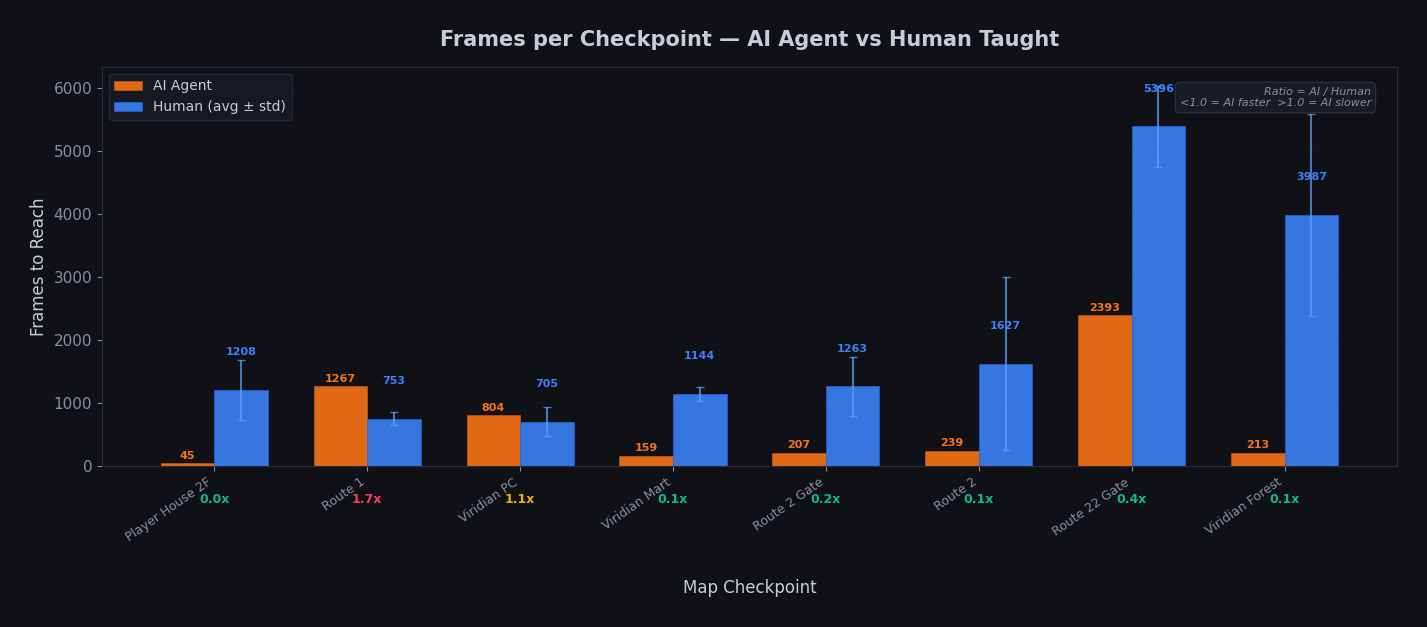

✅ Saved: C:\Users\HP\Documents\cogai\jsons\log_analysis\plot1_frames_per_checkpoint.png


In [7]:
# ============================================================
# CELL 4: Plot 1 — Frames per Checkpoint (Bar Chart)
# ============================================================
# Side-by-side bars showing how many frames the AI vs Human
# took to reach each matched map. This is the core efficiency
# metric — fewer frames = faster navigation to that map.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

labels = [c['name'] for c in comparison]
x = np.arange(len(labels))
bar_width = 0.35

# AI bars
ai_vals = [c['ai_frames'] for c in comparison]
bars_ai = ax.bar(x - bar_width/2, ai_vals, bar_width,
                 color=COLOR_AI, label='AI Agent', alpha=0.9,
                 edgecolor='#c2610f', linewidth=0.5)

# Human bars with error bars
human_vals = [c['human_frames'] for c in comparison]
human_errs = [c['human_frames_std'] for c in comparison]
bars_human = ax.bar(x + bar_width/2, human_vals, bar_width,
                    color=COLOR_HUMAN, label='Human (avg ± std)', alpha=0.9,
                    edgecolor='#2563eb', linewidth=0.5,
                    yerr=human_errs, capsize=3, error_kw={'ecolor': '#60a5fa', 'alpha': 0.7})

# Value labels on bars
for bar, val in zip(bars_ai, ai_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                f'{val}', ha='center', va='bottom', fontsize=8,
                color=COLOR_AI, fontweight='bold')

for bar, val in zip(bars_human, human_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(human_errs)*0.3 + 40,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8,
                color=COLOR_HUMAN, fontweight='bold')

# Efficiency ratio annotations below x-axis
for i, c in enumerate(comparison):
    ratio = c['efficiency_ratio']
    color = COLOR_ACCENT if ratio < 1.0 else COLOR_WARN if ratio > 1.5 else '#eab308'
    ax.text(x[i], -max(ai_vals + human_vals) * 0.08,
            f'{ratio:.1f}x', ha='center', va='top', fontsize=9,
            color=color, fontweight='bold')

ax.set_xlabel('Map Checkpoint', fontsize=12, labelpad=25)
ax.set_ylabel('Frames to Reach', fontsize=12)
ax.set_title('Frames per Checkpoint — AI Agent vs Human Taught', fontsize=15, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Add ratio label legend
ax.text(0.98, 0.95, 'Ratio = AI / Human\n<1.0 = AI faster  >1.0 = AI slower',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        color='#8890a0',
        style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#181c25', edgecolor='#2a2e3a'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot1_frames_per_checkpoint.png'))
plt.show()
print(f"✅ Saved: {os.path.join(OUTPUT_DIR, 'plot1_frames_per_checkpoint.png')}")

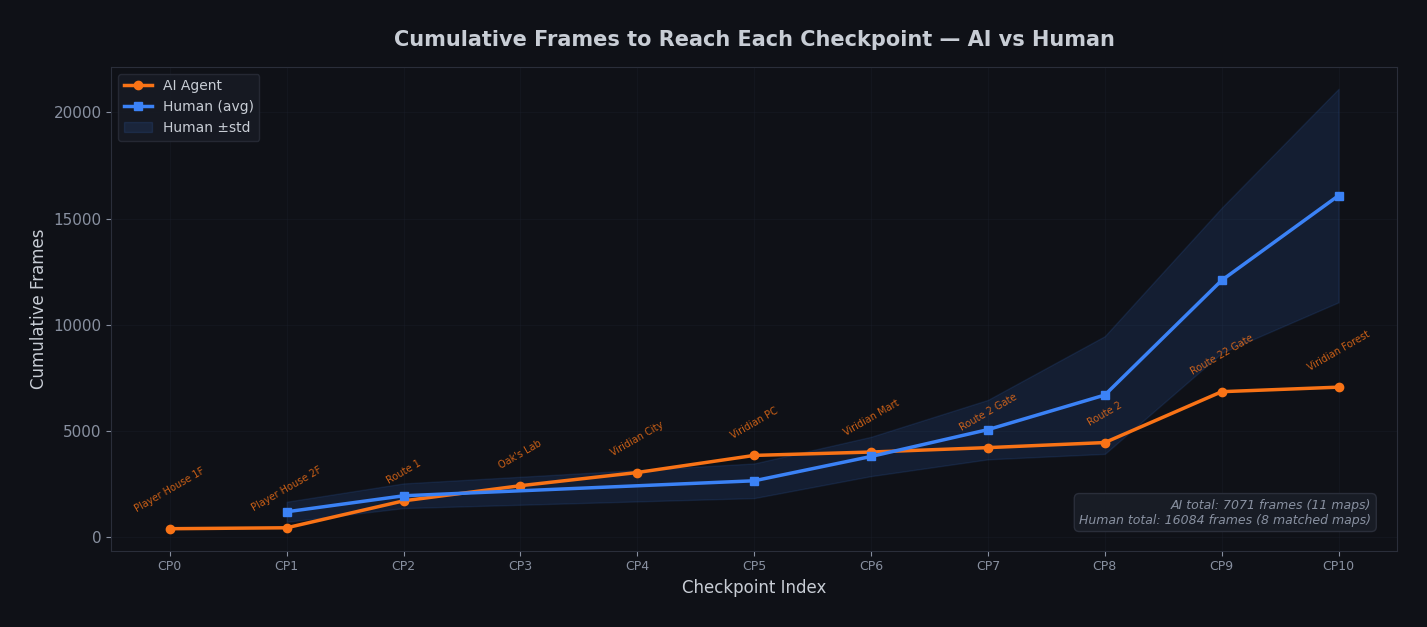

✅ Saved: C:\Users\HP\Documents\cogai\jsons\log_analysis\plot2_cumulative_frames.png


In [8]:
# ============================================================
# CELL 5: Plot 2 — Cumulative Frames Timeline
# ============================================================
# Running total of frames as maps are discovered. Shows the
# overall pace of progression — steeper = slower, flatter =
# faster navigation between checkpoints.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# ── AI cumulative (all checkpoints in visit order) ─────────
ai_maps_ordered = []
ai_cum_frames = []
running = 0
for cp in ai_checkpoints:
    running += cp['frames_from_previous']
    ai_maps_ordered.append(map_name(cp['map_id']))
    ai_cum_frames.append(running)

# ── Human cumulative (matched maps only, in AI visit order) ─
# We accumulate human avg frames in the same map order the AI visited
human_maps_ordered = []
human_cum_frames = []
human_cum_lower = []
human_cum_upper = []
running_h = 0
running_std = 0
for cp in ai_checkpoints:
    mid = cp['map_id']
    if mid in human_by_map:
        h = human_by_map[mid]
        running_h += h['avg_frames']
        running_std += h['std_frames']
        human_maps_ordered.append(map_name(mid))
        human_cum_frames.append(running_h)
        human_cum_lower.append(running_h - running_std)
        human_cum_upper.append(running_h + running_std)

# ── Plot AI line ───────────────────────────────────────────
ax.plot(range(len(ai_cum_frames)), ai_cum_frames,
        color=COLOR_AI, linewidth=2.5, marker='o', markersize=6,
        label='AI Agent', zorder=3)

# Annotate AI points
for i, (name, val) in enumerate(zip(ai_maps_ordered, ai_cum_frames)):
    ax.annotate(name, (i, val), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=7,
                color=COLOR_AI, alpha=0.8, rotation=30)

# ── Plot Human line (only at matched indices) ──────────────
# Map human points to the correct x positions (AI checkpoint indices where maps match)
human_x_positions = []
for i, cp in enumerate(ai_checkpoints):
    if cp['map_id'] in human_by_map:
        human_x_positions.append(i)

ax.plot(human_x_positions, human_cum_frames,
        color=COLOR_HUMAN, linewidth=2.5, marker='s', markersize=6,
        label='Human (avg)', zorder=3)

# Human std band
ax.fill_between(human_x_positions, human_cum_lower, human_cum_upper,
                color=COLOR_HUMAN, alpha=0.12, label='Human ±std')

# ── Formatting ─────────────────────────────────────────────
ax.set_xlabel('Checkpoint Index', fontsize=12)
ax.set_ylabel('Cumulative Frames', fontsize=12)
ax.set_title('Cumulative Frames to Reach Each Checkpoint — AI vs Human', fontsize=15, pad=15)
ax.set_xticks(range(len(ai_cum_frames)))
ax.set_xticklabels([f'CP{i}' for i in range(len(ai_cum_frames))], fontsize=9)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='both', alpha=0.3)
ax.set_axisbelow(True)

# Summary annotation
ax.text(0.98, 0.05,
        f'AI total: {ai_cum_frames[-1]} frames ({len(ai_cum_frames)} maps)\n'
        f'Human total: {human_cum_frames[-1]:.0f} frames ({len(human_cum_frames)} matched maps)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        color='#8890a0', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#181c25', edgecolor='#2a2e3a'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot2_cumulative_frames.png'))
plt.show()
print(f"✅ Saved: {os.path.join(OUTPUT_DIR, 'plot2_cumulative_frames.png')}")

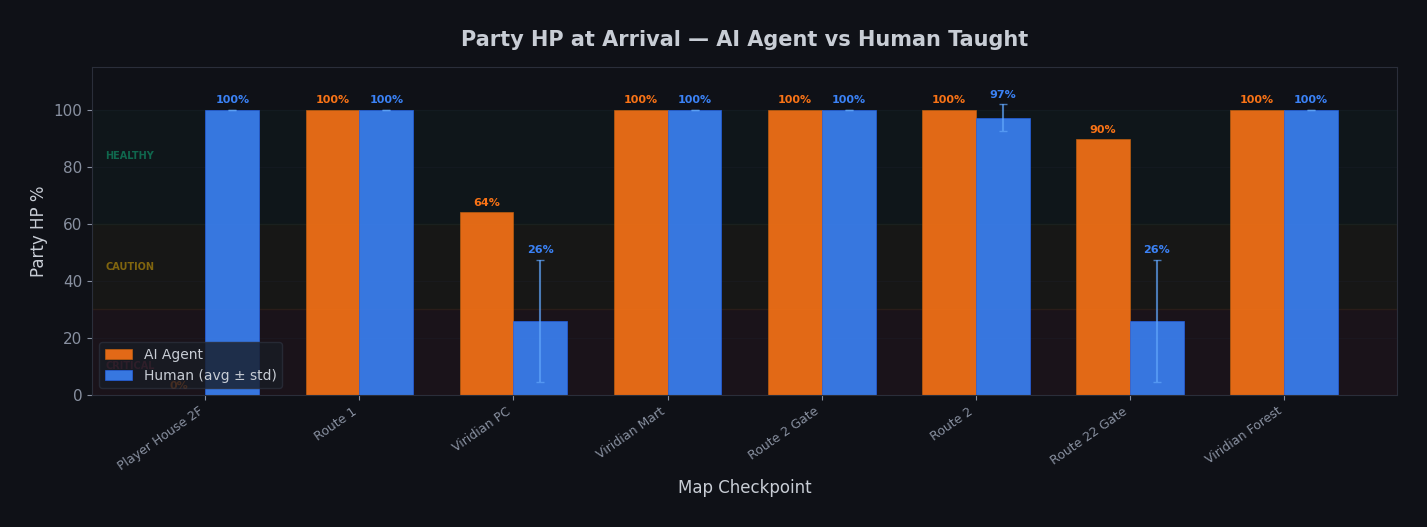

✅ Saved: C:\Users\HP\Documents\cogai\jsons\log_analysis\plot4_hp_at_arrival.png


In [9]:
# ============================================================
# CELL 7: Plot 4 — HP at Arrival (Bar Chart)
# ============================================================
# Compares average party HP ratio when the AI vs Human first
# reached each matched map. Higher HP = better resource
# management, arriving healthier for the next segment.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

labels = [c['name'] for c in comparison]
x = np.arange(len(labels))
bar_width = 0.35

# AI bars
ai_hp = [c['ai_hp'] * 100 for c in comparison]
bars_ai = ax.bar(x - bar_width/2, ai_hp, bar_width,
                 color=COLOR_AI, label='AI Agent', alpha=0.9,
                 edgecolor='#c2610f', linewidth=0.5)

# Human bars with error bars
human_hp = [c['human_hp'] * 100 for c in comparison]
human_hp_errs = [c['human_hp_std'] * 100 for c in comparison]
bars_human = ax.bar(x + bar_width/2, human_hp, bar_width,
                    color=COLOR_HUMAN, label='Human (avg ± std)', alpha=0.9,
                    edgecolor='#2563eb', linewidth=0.5,
                    yerr=human_hp_errs, capsize=3,
                    error_kw={'ecolor': '#60a5fa', 'alpha': 0.7})

# Value labels
for bar, val in zip(bars_ai, ai_hp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
            color=COLOR_AI, fontweight='bold')

for bar, val, err in zip(bars_human, human_hp, human_hp_errs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 1.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
            color=COLOR_HUMAN, fontweight='bold')

# Color-coded HP zones
ax.axhspan(0, 30, color=COLOR_WARN, alpha=0.05, zorder=0)
ax.axhspan(30, 60, color='#eab308', alpha=0.04, zorder=0)
ax.axhspan(60, 100, color=COLOR_ACCENT, alpha=0.03, zorder=0)

ax.text(0.01, 0.08, 'CRITICAL', transform=ax.transAxes, fontsize=7,
        color=COLOR_WARN, alpha=0.5, fontweight='bold')
ax.text(0.01, 0.38, 'CAUTION', transform=ax.transAxes, fontsize=7,
        color='#eab308', alpha=0.5, fontweight='bold')
ax.text(0.01, 0.72, 'HEALTHY', transform=ax.transAxes, fontsize=7,
        color=COLOR_ACCENT, alpha=0.5, fontweight='bold')

ax.set_xlabel('Map Checkpoint', fontsize=12)
ax.set_ylabel('Party HP %', fontsize=12)
ax.set_title('Party HP at Arrival — AI Agent vs Human Taught', fontsize=15, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.legend(loc='lower left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot4_hp_at_arrival.png'))
plt.show()
print(f"✅ Saved: {os.path.join(OUTPUT_DIR, 'plot4_hp_at_arrival.png')}")

Stagnation types:
  Shared:     ['action_pattern', 'action_repeat', 'area_grinding']
  AI only:    ['backtracking', 'position_stuck']
  Human only: ['no_map_progress']


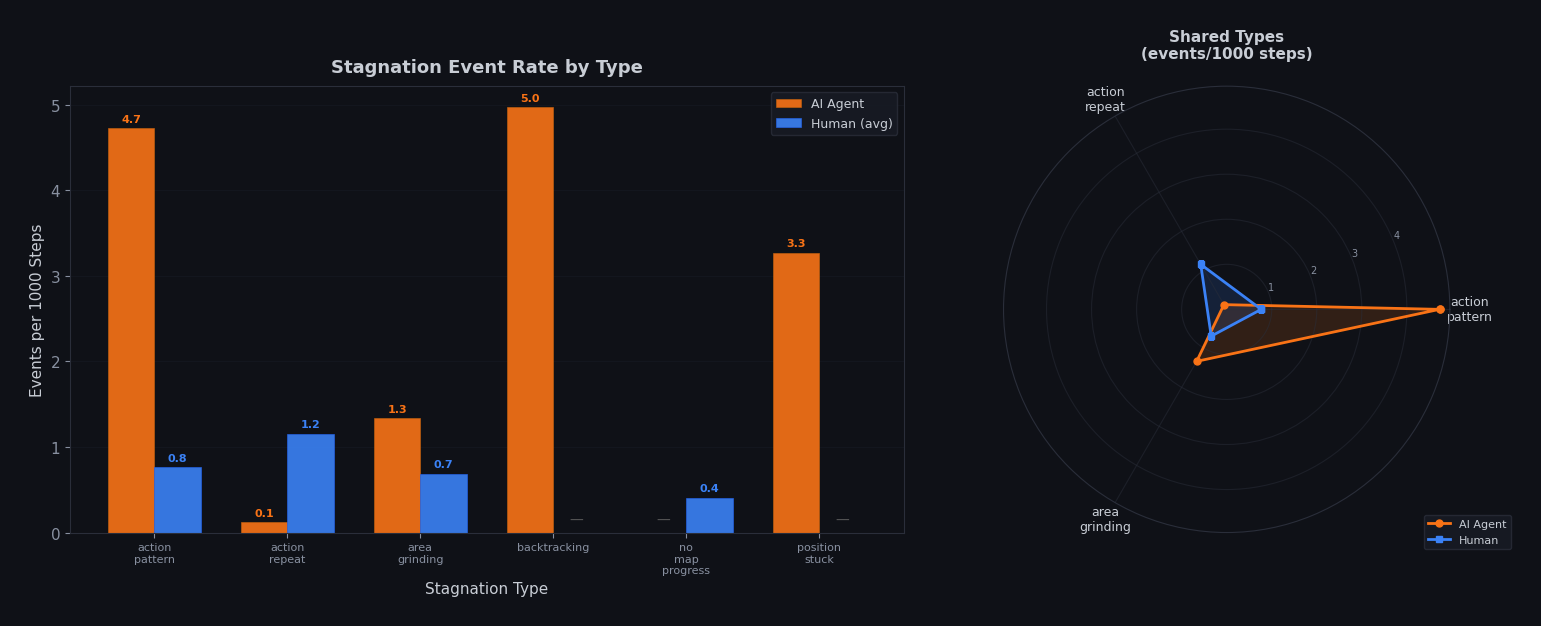

✅ Saved: C:\Users\HP\Documents\cogai\jsons\log_analysis\plot5_stagnation_breakdown.png


In [10]:
# ============================================================
# CELL 8: Plot 5 — Stagnation Type Breakdown (Radar + Bar)
# ============================================================
# Compares stagnation type distributions between AI and Human.
# Note: AI and Human use partially different stagnation types.
#   Shared: action_pattern, action_repeat, area_grinding
#   AI only: position_stuck, backtracking
#   Human only: no_map_progress
# We show both a radar (shared types) and a full bar breakdown.
# ============================================================

# ── Normalize AI stagnation per-type to events per 1000 steps ──
ai_per_1k = {}
for stype, stats in ai_type_stats.items():
    ai_per_1k[stype] = stats['count'] / ai_dedup['total_steps'] * 1000

# ── Normalize Human stagnation per-type to events per 1000 steps ──
human_per_1k = {}
human_avg_steps = human_stag['aggregated_overall']['avg_total_timesteps']
for stype, data in human_stag['aggregated_by_type'].items():
    human_per_1k[stype] = data['avg_count'] / human_avg_steps * 1000

# ── All types across both ──────────────────────────────────
all_types = sorted(set(list(ai_per_1k.keys()) + list(human_per_1k.keys())))
shared_types = sorted(set(ai_per_1k.keys()) & set(human_per_1k.keys()))

print("Stagnation types:")
print(f"  Shared:     {shared_types}")
print(f"  AI only:    {sorted(set(ai_per_1k.keys()) - set(human_per_1k.keys()))}")
print(f"  Human only: {sorted(set(human_per_1k.keys()) - set(ai_per_1k.keys()))}")

# ── Figure: Radar (shared) + Bar (all types) ───────────────
fig, (ax_bar, ax_radar) = plt.subplots(1, 2, figsize=(16, 6),
                                        gridspec_kw={'width_ratios': [1.3, 1]},
                                        subplot_kw={'polar': False})

# ── Left: Full bar chart (all types) ──────────────────────
type_labels = [t.replace('_', '\n') for t in all_types]
x = np.arange(len(all_types))
bar_width = 0.35

ai_bar_vals = [ai_per_1k.get(t, 0) for t in all_types]
human_bar_vals = [human_per_1k.get(t, 0) for t in all_types]

bars1 = ax_bar.bar(x - bar_width/2, ai_bar_vals, bar_width,
                   color=COLOR_AI, label='AI Agent', alpha=0.9,
                   edgecolor='#c2610f', linewidth=0.5)
bars2 = ax_bar.bar(x + bar_width/2, human_bar_vals, bar_width,
                   color=COLOR_HUMAN, label='Human (avg)', alpha=0.9,
                   edgecolor='#2563eb', linewidth=0.5)

# Value labels
for bar, val in zip(bars1, ai_bar_vals):
    if val > 0:
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8,
                    color=COLOR_AI, fontweight='bold')

for bar, val in zip(bars2, human_bar_vals):
    if val > 0:
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8,
                    color=COLOR_HUMAN, fontweight='bold')

# Mark missing types
for i, t in enumerate(all_types):
    if t not in ai_per_1k:
        ax_bar.text(x[i] - bar_width/2, 0.1, '—', ha='center', fontsize=10, color='#555')
    if t not in human_per_1k:
        ax_bar.text(x[i] + bar_width/2, 0.1, '—', ha='center', fontsize=10, color='#555')

ax_bar.set_xlabel('Stagnation Type', fontsize=11)
ax_bar.set_ylabel('Events per 1000 Steps', fontsize=11)
ax_bar.set_title('Stagnation Event Rate by Type', fontsize=13, pad=10)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(type_labels, fontsize=8)
ax_bar.legend(loc='upper right', fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)
ax_bar.set_axisbelow(True)

# ── Right: Radar chart (shared types only) ─────────────────
ax_radar.remove()
ax_radar = fig.add_subplot(122, polar=True)
ax_radar.set_facecolor('#0f1117')

angles = np.linspace(0, 2 * np.pi, len(shared_types), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

ai_radar_vals = [ai_per_1k[t] for t in shared_types] + [ai_per_1k[shared_types[0]]]
human_radar_vals = [human_per_1k[t] for t in shared_types] + [human_per_1k[shared_types[0]]]

ax_radar.plot(angles, ai_radar_vals, 'o-', color=COLOR_AI, linewidth=2, label='AI Agent', markersize=5)
ax_radar.fill(angles, ai_radar_vals, color=COLOR_AI, alpha=0.15)

ax_radar.plot(angles, human_radar_vals, 's-', color=COLOR_HUMAN, linewidth=2, label='Human', markersize=5)
ax_radar.fill(angles, human_radar_vals, color=COLOR_HUMAN, alpha=0.15)

radar_labels = [t.replace('_', '\n') for t in shared_types]
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=9, color='#c8cdd5')
ax_radar.set_title('Shared Types\n(events/1000 steps)', fontsize=11, pad=20, color='#c8cdd5')
ax_radar.legend(loc='lower right', fontsize=8, bbox_to_anchor=(1.15, -0.05))
ax_radar.grid(color='#2a2e3a', alpha=0.5)
ax_radar.tick_params(axis='y', labelsize=7, colors='#8890a0')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot5_stagnation_breakdown.png'))
plt.show()
print(f"✅ Saved: {os.path.join(OUTPUT_DIR, 'plot5_stagnation_breakdown.png')}")

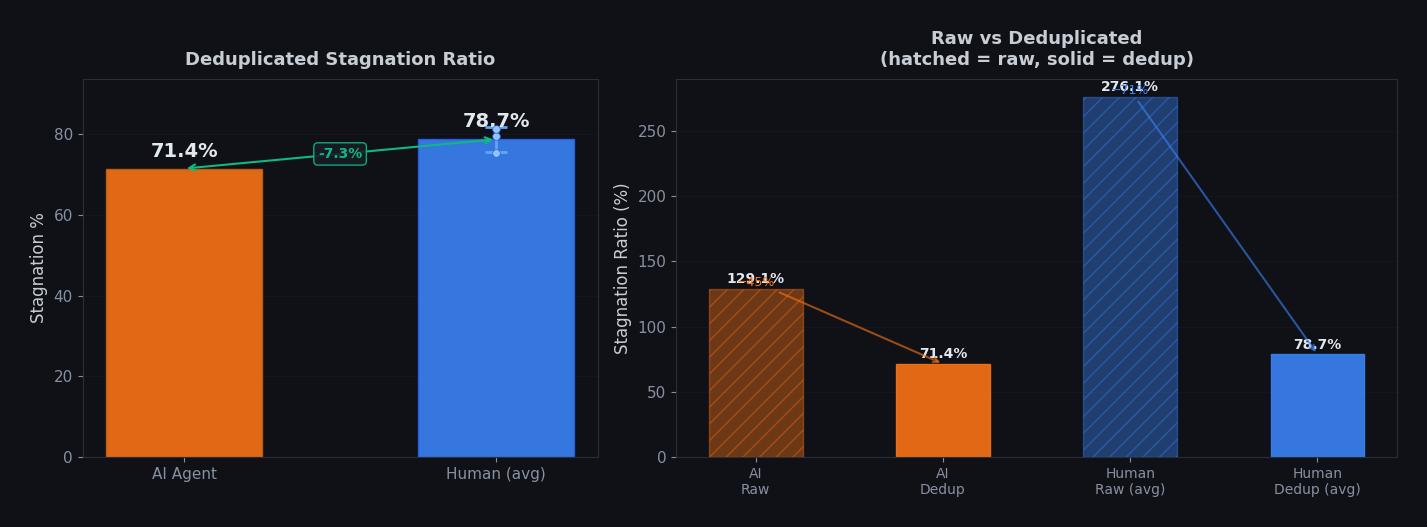

✅ Saved: C:\Users\HP\Documents\cogai\jsons\log_analysis\plot6_stagnation_ratio.png


In [11]:
# ============================================================
# CELL 9: Plot 6 — Stagnation Ratio Comparison
# ============================================================
# Head-to-head comparison of deduplicated stagnation ratios.
# Shows what percentage of total session time was spent in
# some form of stagnation, after merging overlapping intervals.
# ============================================================

fig, (ax_main, ax_detail) = plt.subplots(1, 2, figsize=(14, 5),
                                          gridspec_kw={'width_ratios': [1, 1.4]})

# ── Left: Overall deduplicated ratio ──────────────────────
ai_ratio = ai_dedup['dedup_ratio']
human_ratio = human_stag['aggregated_overall']['avg_deduplicated_stagnation_ratio']
human_ratio_std = human_stag['aggregated_overall']['std_deduplicated_stagnation_ratio']

# Per-run human ratios for scatter
human_run_ratios = [r['deduplicated_stagnation_ratio'] for r in human_stag['aggregated_overall']['per_run']]

bars = ax_main.bar([0, 1], [ai_ratio * 100, human_ratio * 100],
                   color=[COLOR_AI, COLOR_HUMAN], alpha=0.9, width=0.5,
                   edgecolor=['#c2610f', '#2563eb'], linewidth=1)

# Error bar on human only
ax_main.errorbar(1, human_ratio * 100, yerr=human_ratio_std * 100,
                 fmt='none', ecolor='#60a5fa', capsize=8, capthick=2, elinewidth=2)

# Human per-run scatter
for i, r in enumerate(human_run_ratios):
    ax_main.scatter(1, r * 100, color='#93c5fd', s=30, zorder=5,
                    edgecolors='#2563eb', linewidths=0.5)

# Value labels
for bar, val in zip(bars, [ai_ratio * 100, human_ratio * 100]):
    ax_main.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=14,
                 color='#e2e8f0', fontweight='bold')

# Difference annotation
diff = ai_ratio - human_ratio
diff_color = COLOR_WARN if diff > 0 else COLOR_ACCENT
ax_main.annotate('', xy=(0, ai_ratio * 100), xytext=(1, human_ratio * 100),
                 arrowprops=dict(arrowstyle='<->', color=diff_color, lw=1.5))
mid_y = (ai_ratio + human_ratio) / 2 * 100
ax_main.text(0.5, mid_y, f'{"+" if diff > 0 else ""}{diff*100:.1f}%',
             ha='center', va='center', fontsize=10, color=diff_color, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#181c25', edgecolor=diff_color, alpha=0.9))

ax_main.set_xticks([0, 1])
ax_main.set_xticklabels(['AI Agent', 'Human (avg)'], fontsize=11)
ax_main.set_ylabel('Stagnation %', fontsize=12)
ax_main.set_title('Deduplicated Stagnation Ratio', fontsize=13, pad=10)
ax_main.grid(axis='y', alpha=0.3)
ax_main.set_axisbelow(True)
ax_main.set_ylim(0, max(ai_ratio, human_ratio) * 100 + 15)

# ── Right: Raw vs Deduplicated breakdown ───────────────────
categories = ['AI\nRaw', 'AI\nDedup', 'Human\nRaw (avg)', 'Human\nDedup (avg)']

ai_raw_ratio = ai_dedup['raw_ratio']
human_raw_ratio = np.mean([r['raw_stagnation_ratio'] for r in human_stag['aggregated_overall']['per_run']])

values = [ai_raw_ratio * 100, ai_ratio * 100, human_raw_ratio * 100, human_ratio * 100]
colors = [COLOR_AI, COLOR_AI, COLOR_HUMAN, COLOR_HUMAN]
alphas = [0.4, 0.9, 0.4, 0.9]
hatches = ['//', '', '//', '']

x_detail = np.arange(len(categories))
for i, (val, col, alpha, hatch) in enumerate(zip(values, colors, alphas, hatches)):
    ax_detail.bar(x_detail[i], val, color=col, alpha=alpha, width=0.5,
                  edgecolor=col, linewidth=1, hatch=hatch)
    ax_detail.text(x_detail[i], val + 2, f'{val:.1f}%', ha='center', va='bottom',
                   fontsize=10, color='#e2e8f0', fontweight='bold')

# Reduction arrows
for src, dst in [(0, 1), (2, 3)]:
    reduction = (values[src] - values[dst]) / values[src] * 100
    mid = (values[src] + values[dst]) / 2
    col = COLOR_AI if src == 0 else COLOR_HUMAN
    ax_detail.annotate(f'−{reduction:.0f}%',
                       xy=(x_detail[dst], values[dst]),
                       xytext=(x_detail[src], values[src]),
                       arrowprops=dict(arrowstyle='->', color=col, lw=1.5, alpha=0.6),
                       fontsize=9, color=col, ha='center', va='bottom')

ax_detail.set_xticks(x_detail)
ax_detail.set_xticklabels(categories, fontsize=10)
ax_detail.set_ylabel('Stagnation Ratio (%)', fontsize=12)
ax_detail.set_title('Raw vs Deduplicated\n(hatched = raw, solid = dedup)', fontsize=13, pad=10)
ax_detail.grid(axis='y', alpha=0.3)
ax_detail.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot6_stagnation_ratio.png'))
plt.show()
print(f"✅ Saved: {os.path.join(OUTPUT_DIR, 'plot6_stagnation_ratio.png')}")